# Introduction to the Digital Twin - Part 1

This notebook will give a simple first illustration the core functionality of the `bluebird-dt` Digital Twin.

We will create a simulated scenario, evolve the state of the simulation, and visualise the results.
We won't go into any details here - the following notebooks in this series will explain more about what is happening under the hood.

In [ ]:
%pip install bluebird-dt matplotlib

### Loading a simple simulation scenario.

When we talk about a *scenario*, we mean the setup for the simulation of an "environment", which contains an "airspace", and a set of "aircraft".   

The airspace may contain one or more *Sector*s, (defined volumes, typically controlled by one Air Traffic Controller), and a number of *Fix*es (navigation waypoints in (latitude, longitude) space). 

Aircraft will have a *Callsign* to identify them, and will have their location defined by latitude, longitude and *Flight Level* (altitude in units of 100ft).   They will be flying at a given *Heading* (0 to 360 degrees), possibly following a *Route* (a series of fixes).

### The "I-Sector Two Aircraft" scenario

The I-sector is a simple rectangular region of airspace, with a north/south orientation, and a few fixes situated on the vertical centre line.   We will load a simple scenario with two aircraft sharing this airspace, one starting at the north of the sector travelling south, and the other one travelling in the opposite direction from the south of the sector.

In [2]:
# import the top-level "Simulator" class.
from bluebird_dt.simulator import Simulator

To load the scenario, we need to provide a scenario "category" and a scenario name.
"Artificial" scenarios are on very simple airspaces, such as the "I-sector", designed to test simple situations.

In [36]:
sim = Simulator.from_category("Artificial", "I-Sector Two Aircraft")

## Visualising the airspace

There are some tools in the `render/radar.py` module for visualising the scenarios using matplotlib.  For more details on this, see the notebook in `examples/render/radar.ipynb`.

In [37]:
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import SVG, Image

%matplotlib inline

In [38]:
from bluebird_dt.core import Pos2D
from bluebird_dt.render import Radar

view_centre = Pos2D.from_str("50.75N 3.5W")
view_width = 60.0  # [nmi] about 1 degree of longitude
aspect_ratio = 1

radar = Radar(view_centre, view_width, aspect_ratio)

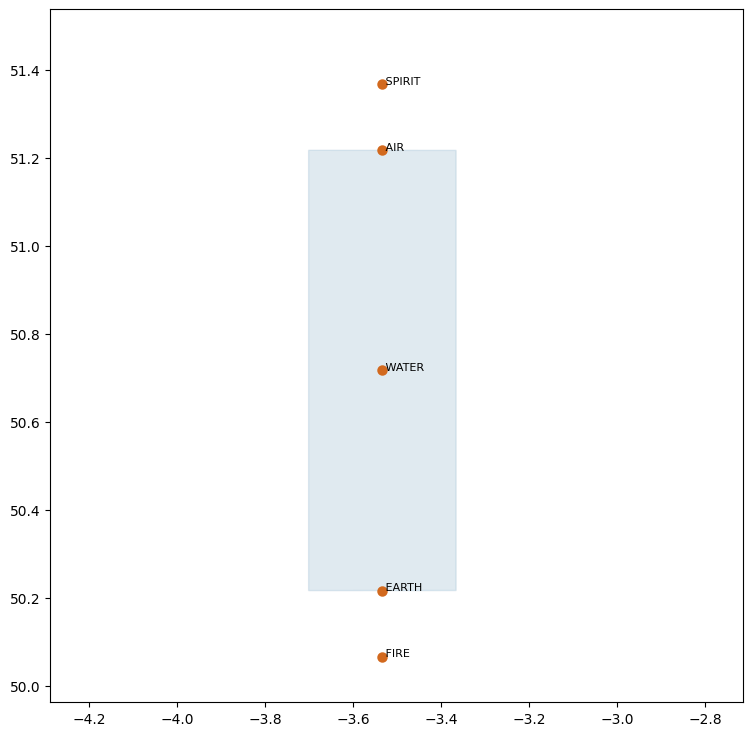

In [39]:
airspace = sim.manager.environment.airspace
radar.draw_airspace(airspace)
plt.show()

Here we see the sector area as the shaded area, and the named points are the fixes.

## Evolving the simulation

We can move the simulation forward by a specified time interval by using the `evolve` method.   We normally choose a time interval of 6 seconds, as this is a typical period at which we can receive radar data for UK airspace.

In [40]:
sim.evolve(6)

True

## Visualising the evolution of the scenario

We can create a short video using the `Radar` class as follows: 

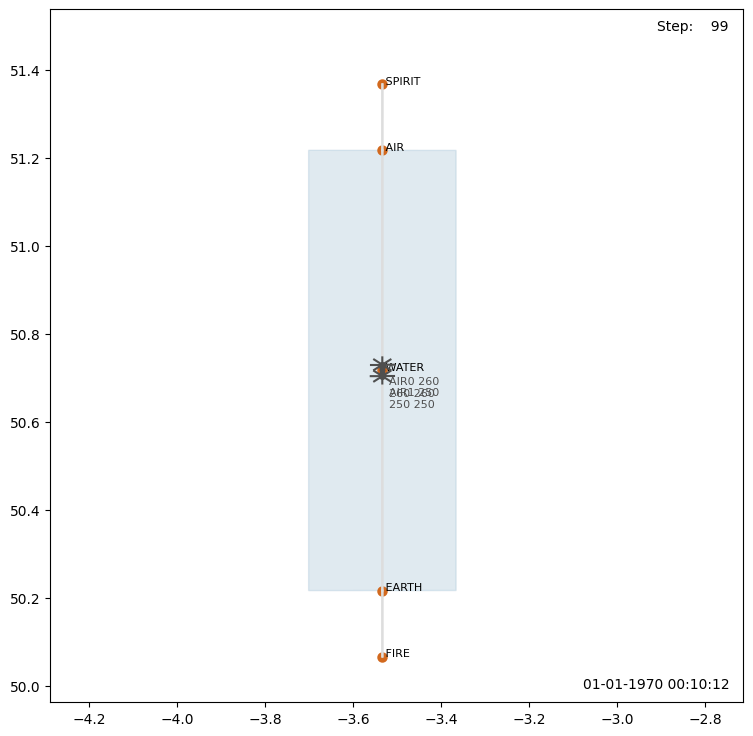

In [41]:
import IPython.display

# the radar is re-instantiated. no need to clear the screen.
radar = Radar(view_centre, view_width, aspect_ratio) # re-introduce the spines/axes

for _ in range(100):
    sim.evolve(6.0)
    figure, ax = radar.draw(sim.manager.environment)

    IPython.display.display(figure) # or IPython.display.display(plt.gcf())
    IPython.display.clear_output(wait=True)

Here we see the two aircraft, with callsigns "AIR0" and "AIR1", entering the sector from opposite ends, moving towards each other.  Next to the marker for each aircraft we can see their current flight level, as well as their "selected flight level" (i.e. the most recent flight level they were instructed to go to) and their "exit flight level" (i.e. the flight level at which they should exit the sector).

### Conclusions and next steps

So far we have used the *Simulator* class to evolve a very simple *scenario* and visualised how the aircraft move in a short animation.

In the next notebook, Intro-Part2, we will look at some more complex scenarios, and how to programmatically access data in the simulation environment.

Future notebooks will show how to configure custom scenarios, look at "predictors" that handle the simulation of aircraft movement, and show how to submit "actions" to the aircraft.